   ... knowing when and how to strengthen the induction hypothesis is ...

   During exam, never start writing your formal `Base Case` until you have
   scanned for the traps. Here is the exact mechanical checklist and the clues
   you should look for.


### CLUE 1: The "Hardceded Accumulator" Red Flag
   Look at the function definitions and the theorems you are asked to prove.
   - Is one of the functions TAIL-RECURSIVE? (Does it use extra arguments to build
     up the answer sas it goes, like `lenA xs acc` or `splitTR zs xs ys`?)
   - Does the target theorem call that function with HARDCODED STARTING VALUES?
     (e.g., `lenA xs 0`, or `splitTR zs [] []`)

   If you see a tail-recursive being called with a `0` or an empty list `[]`
   in the target theorem, ALARM BELLS... There's a 90% guarantee that a standard
   property $P$ will be too weak.


### Clue 2: The 30-Second Scratchpad Test
   If you suspect the property is too weak, do not start writing the proof yet. 
   Go to a piece of scratch paper and "test" the recursive engine.

   Unroll the recursive function exactly ONE STEP, starting from the hardcoded
   values:
   1. `splitTR ((x,y):zs) [] []`
   2. `-> splitTR zs ([]++[x]) ([]++[y])`
   3. `-> splitTR zs [x] [y]`

   Now, look at the result: `splitTR zs [x] [y]`

   Ask yourself: If my Inductive Hypothesis only gives me a rule for 
   `splitTR zs [] []`, can I use it here?

   No. `[x]` is not `[]`. The function has mutated the accumulator, and you
   are locked out. The standard induction fails. 


### The Mechanical Fix: How to construct $Q$
   Once you know the standard $P$ is broken, constructing $Q$ is a purely
   mechanical process.

   1. Identify the mutating slots: In `lenA xs 0`, the `0` mutated. In 
      `splitTR zs [] []`, both `[]`s mutated.
   2. RIP OUT THE CONSTANTS: Replace those hardcoded values with completely fresh
      variable names.
      - `lenA xs 0` -> `lenA xs a`
      - `splitTR zs [] []` -> `splitTR zs xs ys`
   3. QUANTIFY THEM: Wrap the whole new property in universal quantifiers for 
      those new variables. 
      - "Let $Q(xs)$ be: $\forall a, `lenA xs a = ...`$"


### THE HIDDNE CLUE IN THE EXAM QUESTION
   Look closely ... 



1. Why is `splitTR` in square brackets `[ ]`? Is it an array?
   NO, IT'S NOT AN ARRAY AT ALL. This is a classic syntax trap. 

   In Haskell, `[]` means a list... But in FOL, square brackets are used as 
   SCOPING BRACKETS for quantifiers.

   When ...

   The `[ ]` jsut acts like a giant set of parentheses. It means: ""... It is
   just the logic syntax to show where the $\forall$ stops applying. 


2. ... `\forall xs, ys` or `\forall xs : [a], ys : [b]` is just a standard
   mathematical shorthand to save space. The comma distributes the universal
   quantifier to both variabels.

   It means the exact same thing... If you prefer to write them separately...


3. "DOES THIS MEAN WE ARE BARELY DOING THE $Q(zs)$ TRICK AT ALL ... ?"
   ... hit the nail on the head... realising that Part (c) feels almost "too
   easy" because you didn't have to invent anything. Part (c) is the $Q(zs)$
   trick, but the examiner did the hardest part for you...
   

-- TYPE DECLARATION: In many implementations of FOL, a colon indicates the sort
   of type of a variable (e.g., $x : Integer$ or $\forall x: Domain$).
   - ALTERNATIVE DEFINITION: While not standard, in some contexts, it can 
     separate a variable from its domain (e.g., ${x : Person | Mortal(x)}$)


---

   ... perfect mental model.

   However, you should drop the idea that it checks whether something "exists."
   Instead, think of it exactly like a UNIT TEST or an ASSERTION in programming.

   ... best way to think about predicates when you see them on this exam.


---
1. The CS Mental Model: A Boolean Function
   In programming terms, a predicate $Q(m, n, i, j , r)$ is literally just a 
   function that takes in those five integers and returns a `Boolean` (`True` or
   `False`).

   If you were writing it in Haskell, the type signature would be:
   `q :: Int -> Int -> Int -> Int -> Int -> Bool`

   Whenever you feed it a set of numbers, it run...


2. CONCRETE PREDICATES vs. ABSTRACT PREDICATEs
   In these exams, you will see preciates used in two different ways:

### Way 1: The Concrete Predicate (The actual test)
   In the `lenA` and `length` question earlier, we explicitly defined what the
   test was. We said: Let $Q(xs)$ be the test: `lenA xs a == length xs + a`.

   Here, $Q$ is a specific mathematical equation. You evaluate the left side,
   evaluate the right side, and if they match, $Q$ is `True`.


### Way 2: The Abstract Predicate (The placeholder)
   In Part (e) of the qeustion we just did, the examiner said: "Assuming some
   predicate $Q$".

   They didn't tell you what the test actually is! It might just be testing if 
   `r == m + n`, or it might be testing if `r > 0`, or if `r` is an even number.

   Why do they do this? Because of that specific question, the EXAMINER DOESN'T
   CARE WHAT THE TEST IS. They are only testoing your ability to build the 
   logical scaffolding (the Inductive Principle). They use the letter $Q$ as a
   blank placeholder, meaning: "Insert whatever property you want to prove
   right here."

### The "First Thought" Rule for the Exam
   When youn are sitting in the exam and you read: "Write the inductive 
   principle for function F using predicate Q," your immedaite thought process
   should be:

   1. "Q is just a blank True/'False template."
   2. "My job is NOT to solve the math."
   3. "My job is to map the Haskell code branches to the Q template."

   If the code has a base case `F(0) = 1`, you write `Q(0, 1)`
   If the code has a recursive case `F(n) = F(n-1) + 2`, you write: "If $Q$ is
   true for the inner call $k$, then $Q$ is true for the outer call $k + 2$."

---

   Take a deep breath. It looks... do NOT need to invent this from scratch.

   ... not a creative math problem. It is a strict, mechanical translation. You
   are acting like a compiler, translating the two lines of math code into a
   formal logic template. 

   If you know the template... can write this out in 30 seconds for any recursive

---
### The "Method": The Fill-in-the-Blanks Template
   Whenever an exam asks you to "write the inductive principle" for a recursive 
   function, they want you to build a machine with three parts:

   $$[Base Case] ^ [Recursive Step] -> [The Conclusion]$$

   You get the Base Case and the Recursive Step DIRECTLY by reading the 
   arguments in the function definition. 

   Let's look at the code they gave you for $P2$:
      - (R3 Base Case): P2(m, m, acc) = ...
      - (R4 Recursive Step): m =/= n -> P2(m, n, acc) = ... P2(m, n + 1, ...)

   The target property you are asked to prove is: THE FIRST ARGUMENT >= THE
   SECOND ARGUMENT. (i.e.g, m >= n).

   Now, let's just fill in the blanks.


### PART 1: The Base Case
   Look at rule R3. The function arguments are exactly (m, m, acc)
   Apply the target property (first argument >= second argument) to those
   specific arguments:
      - First argument is $m$. Second argument is $m$.
      - Property becomes: $m >= m$.
      - RESULT: $[\forall m, acc \in Z. m >= m]$


### PART 2: The Recursive Step
   Look at rule R4. This is an `if` statement.

   If the condition is met, AND if the property holds for the inner recursive call,
   THEN the property holds for the outer call.

   - THE CONDITION: The code says m /= n
   - THE INNER CALL: The code calls P2(m, n+1, ...). Apply our target property
     (1st >= 2nd) to these arguments. It becomes m >= n + 1.
   - THE OUTER CALL (Targret): The outer function is P2(m, n, acc)  


   ...
---
## The "Domino" Rule
   Remember, this entire block is an INDUTIVE PRINCIPLE. The whole point of 
   induction is the domino effect?: you can onlu prove the current step works
   by assuming the next/inner step works. 

   When you write the recursive step for the principle, you are setting up
   the logic for:
      [We are in the loop] ^ [Assume the inner function call obeys the rule] -->
         [Proce the outer function call obeys the rule]

   1. THE CONDITION: $m /= n$. (This just confirms we are actually taking a 
      recursive step, not hitting the base case).
   2. THE INNER CALL (The Assumption / IH): The code forces us to call
      P2(m, n+1, ...). If we want to prove this whole system works, we MUST
      demand that this inner call satisfies our target property. Since our
      target property is "First Argument >= Second Argument", and the
      inner call's arguments are m and n + 1, we substitute them in: m >= n + 1.
   3. THE OUTER CALL (The Target): The code we are currently evaluating is 
      $P2(m, n, ...)$. Our target property applied to these arguments is m >= n.   


---

   ... we are moving away from proving mathematical truths and into proving that
   code actually does what it claims to do. To survive these questions, ...
   read the mathematical notation like a native speaker. Here is the conceptual
   breakdown of B1. 


---
## 1. The Time-Travel Variables (x vs x_pre vs x_old)

### The Intuition:
   In maths, $x$ is just a static number. In programming, $x$ changes over time.
   We need a way to talk about the "past versions" of variables inside our 
   mathematical proofs.
   - $x$ (Current State): The value of $x$ right at this exact line of code.
   - $x_pre$ (Function Entry): The value of $x$ at the very moment the function
     was called. This is your "original baseline".
   - $x_old$ (Loop Entry): The value of $x$ at the moment the current loop 
     iteration started. (You mostly use this later when proving loop invariants).

   EXAMPLE: If I pass $x = 5$ into a function, and the first line is $x++$, then 
   right after that line: x=6, but x_pre=5.


---
## 2. ARRAY RANGES AND THE "HALF-OPEN" SECRET ([..))

### The Intuition:
   Imperial almost exclusively uses HALF-OPEN INTERVALS for arrays. It looks like
   this: $a[x..y)$.
      - The `[` means "Inclusive": Starts exactly at index $x$.
      - The `)` means "Exclusive": Stop right before index $y$.

### Why do we do this?
   Becuase it makes the math beautifully clean:
      - The length of the slice `a[x..y)` is always exactly y - x.
      - If you split an array at index $k$, the two halves snap together
        perfectly: $a[0..k)$ and $a[k..size)$.
           * No me messy +1 or -1 overlaps.
      - a[..) is just shorthand for the entire array: $a[0..size)$     


---
## 3. ARRAY EQUIVALENCE (~ vs \approx)

### The Intuition:









---

   ... 
   - $\approx$ (Deep Equality): The two arrays are PERFECT IDENTICAL TWINS. They
     have the exact same size, and the exact same elements in the exact same 
     order. (i.e., $a[k] == b[k]$ for every index).
   - $~$ (Permutation): The two arrays contain the EXACT SAME ITEMS, BUT POSSIBLY
     SCRAMBLED. No items were deleted, and no fake items were invented. They are
     anagrams of each other. 

   Whenever you write a sorting algorithm or a shuffling function, the classic
   post-condition is: `POST: a[..] ~ a[..]pre`. This proves you actually sorted
   the user's original data, rather than just returning a brand new array of 
   zeros.


---
## Decoding the Array Lemmas Cheatsheet

---
## 1. Deep Equality Lemmas ($\approx$)
   These rule states that Deep Equality acts exactly like a normal "equals" sign.
   - ≈Symm: If a ≈ b, then b ≈ a. (Order of variables don't matter).
   - ≈Trans: If a ≈ b and b ≈ c, then a ≈ c. (If A identical B... A identical to C...)
   - ≈Size: If a ≈ b, then a.size == b.size.
   - ≈IsPrm: If a ≈ b -> a ~ b. (If two arrays are perfectly identical, they
     are technically also a permutation of each other--just a permutation where
     nothing moved).


## 2. Permutation Lemmas (~)
   These rules state that "being a scrambled version of" acts like an equal sign.
   - ~Symm: If a is a scramble of b, b is a scramble of a.
   - ~Trans: If you scramble an array twice (a ~ b and b ~ c), the final array
     is still just a scramble of the first one (a ~ c).
   - ~Size: Permuting an array doesn't change its size.


## 3. Swapped Lemmas
   `Swapped(a[..], b[..], i, j)` is a specific function that returns True if 
   array $a$ is exactly the same as array $b$, EXCEPT the items at index $i$ and
   index $j$ have traded places.
   - ~Swpd: $Swapped(a[..], b[..], i, j)$ --> a[..] ~ b[..]. If you swap two
     elements, the new array is a permutation of the old one. This is the 
     absolute core lemma you use when proving that a sorting algorithm (like
     Bubble Sort) doesn't lose data.   

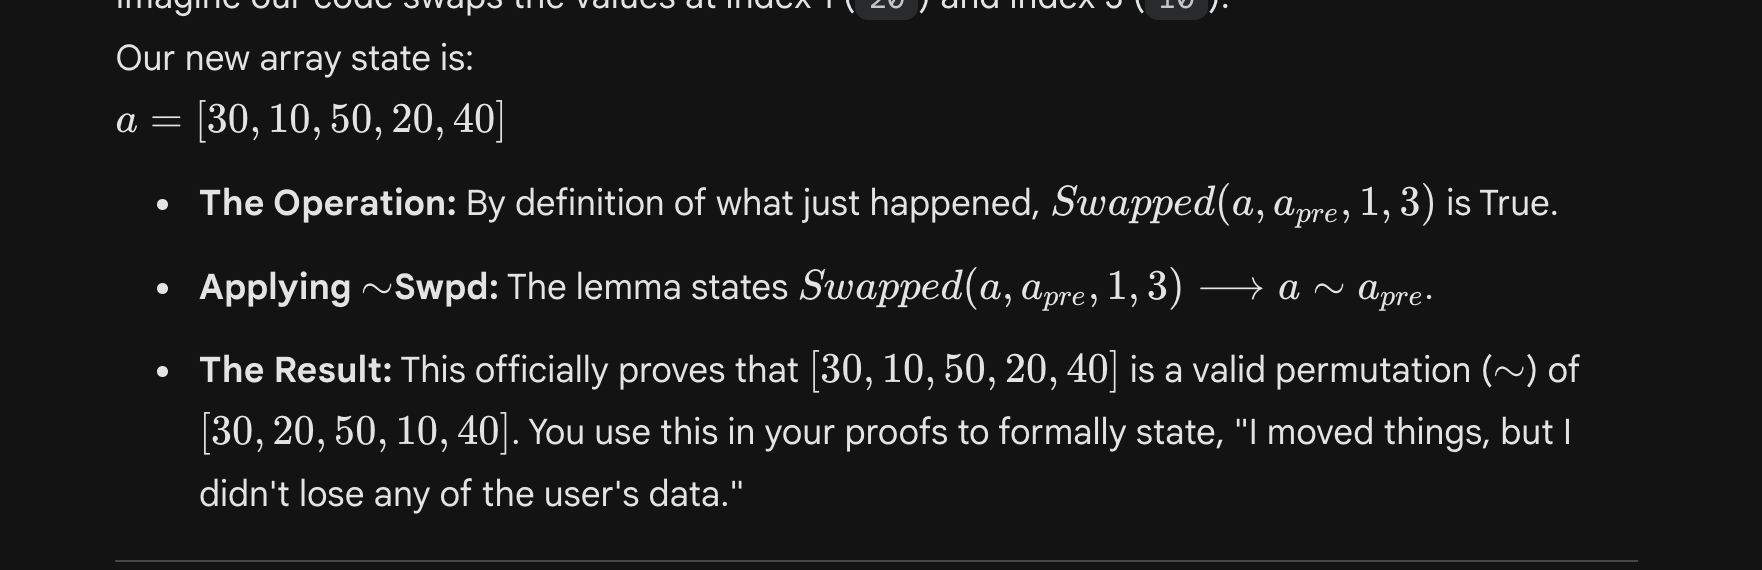

---

## RngWeak (Range Weaken)
   This is about making a "weaker" claim.

   Suppose your code modifies the array $b$ only at index `2`.

   $b = [30, 20, 99, 10, 40]$

   - THE STRONG CLAIM: $b$ is identical to $a_pre$, except strictly in the tiny
     window $[2..3)$
   - THE WEAKER CLAIM: Sometimes your loop invariant isn't that precise. It might
     just say, "The array might be modified anywhere between index `1` and `4`".
   - THE RULE: `RngWeak` lets you mathematically expand the "danger zone". If
     $b$ only differs from $a_pre$ inside [2..3), it is perfectly legal to say
     it differs from $a_pre$ inside the wider window [1..4).
